### Sentiment analiza

#### Učitavanje potrebnih biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
# nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import defaultdict
from plotly import subplots
import plotly.graph_objs as go
import plotly.offline as py
# nltk.download('wordnet')
import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\katar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Učitavanje dataset-a

In [2]:
dataset = pd.read_csv("Amazon_Reviews.csv", index_col=False)

#### Analiza dataset-a

In [3]:
dataset.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [4]:
dataset.describe(include='object')

,Product Name,Brand Name,Reviews
count,413840,348669,413770
unique,4410,384,162490
top,Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...,Samsung,Good
freq,1451,65747,2879


In [5]:
dataset.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

#### Preprocesiranje dataset-a

##### Ekstrakcija potrebnih atributa

In [6]:
filtered_dataset = dataset[['Reviews', 'Rating']].copy()
filtered_dataset.head()

,Reviews,Rating
0,I feel so LUCKY to have found this used (phone...,5
1,"nice phone, nice up grade from my pantach revu...",4
2,Very pleased,5
3,It works good but it goes slow sometimes but i...,4
4,Great phone to replace my lost phone. The only...,4


##### Enkodiranje feature-a

In [7]:
def encode_rating(rating: int) -> str:
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

In [8]:
filtered_dataset['Label'] = filtered_dataset['Rating'].apply(encode_rating) 
filtered_dataset.drop('Rating', axis=1, inplace=True)
print("Unique values of Label: ", filtered_dataset['Label'].unique())
filtered_dataset.head()

Unique values of Label:  ['Positive' 'Negative' 'Neutral']


,Reviews,Label
0,I feel so LUCKY to have found this used (phone...,Positive
1,"nice phone, nice up grade from my pantach revu...",Positive
2,Very pleased,Positive
3,It works good but it goes slow sometimes but i...,Positive
4,Great phone to replace my lost phone. The only...,Positive


##### Uklanjanje nedostajućih vrednosti

In [9]:
print("Dataset shape before dropping: ", filtered_dataset.shape)
filtered_dataset.dropna(inplace=True)
print("Dataset shape after dropping: ", filtered_dataset.shape)

Dataset shape before dropping:  (413840, 2)
Dataset shape after dropping:  (413770, 2)


In [10]:
filtered_dataset.describe()

,Reviews,Label
count,413770,413770
unique,162490,3
top,Good,Positive
freq,2879,284948


In [11]:
filtered_dataset.head()

,Reviews,Label
0,I feel so LUCKY to have found this used (phone...,Positive
1,"nice phone, nice up grade from my pantach revu...",Positive
2,Very pleased,Positive
3,It works good but it goes slow sometimes but i...,Positive
4,Great phone to replace my lost phone. The only...,Positive


In [12]:
non_preprocessed_dataset = filtered_dataset.copy()

##### Čišćenje review-a

In [13]:
def removing_url(review: str) -> str:
    return re.sub(r'http\S+', '', review)

def clean_non_alphanumeric(review: str) -> str:
    return re.sub('[^a-zA-Z]', ' ', review)

def convert_to_lowercase(review: str) -> str:
    return str(review).lower()

def tokenize_text(review_text: str) -> str:
    return word_tokenize(review_text)

In [14]:
filtered_dataset['CleanReviews'] = filtered_dataset['Reviews'].apply(removing_url)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(clean_non_alphanumeric)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(convert_to_lowercase)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(tokenize_text)

In [15]:
filtered_dataset = filtered_dataset.replace('', pd.NA).dropna()
print(filtered_dataset.shape)
filtered_dataset.head()

(413770, 3)


,Reviews,Label,CleanReviews
0,I feel so LUCKY to have found this used (phone...,Positive,"[i, feel, so, lucky, to, have, found, this, us..."
1,"nice phone, nice up grade from my pantach revu...",Positive,"[nice, phone, nice, up, grade, from, my, panta..."
2,Very pleased,Positive,"[very, pleased]"
3,It works good but it goes slow sometimes but i...,Positive,"[it, works, good, but, it, goes, slow, sometim..."
4,Great phone to replace my lost phone. The only...,Positive,"[great, phone, to, replace, my, lost, phone, t..."


In [16]:
def remove_stopwords(token: str) -> list[str]:
    stop_words = set(stopwords.words('english'))
    return [item for item in token if item not in stop_words]

def lemmatization(review_text: str) -> list[str]:
    lemma = WordNetLemmatizer()
    return [lemma.lemmatize(word=token, pos='v') for token in review_text]

In [17]:
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(remove_stopwords)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(lemmatization)

In [18]:
filtered_dataset.head(15)

,Reviews,Label,CleanReviews
0,I feel so LUCKY to have found this used (phone...,Positive,"[feel, lucky, find, use, phone, us, use, hard,..."
1,"nice phone, nice up grade from my pantach revu...",Positive,"[nice, phone, nice, grade, pantach, revue, cle..."
2,Very pleased,Positive,[please]
3,It works good but it goes slow sometimes but i...,Positive,"[work, good, go, slow, sometimes, good, phone,..."
4,Great phone to replace my lost phone. The only...,Positive,"[great, phone, replace, lose, phone, thing, vo..."
5,I already had a phone with problems... I know ...,Negative,"[already, phone, problems, know, state, use, d..."
6,The charging port was loose. I got that solder...,Negative,"[charge, port, loose, get, solder, need, new, ..."
7,"Phone looks good but wouldn't stay charged, ha...",Negative,"[phone, look, good, stay, charge, buy, new, ba..."
8,I originally was using the Samsung S2 Galaxy f...,Positive,"[originally, use, samsung, galaxy, sprint, wan..."
9,It's battery life is great. It's very responsi...,Neutral,"[battery, life, great, responsive, touch, issu..."


In [19]:
def convert_list_of_tokens_to_string(reviews_list: list) -> str:
    return ' '.join(reviews_list)

In [20]:
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(convert_list_of_tokens_to_string)

In [21]:
filtered_dataset = filtered_dataset[ filtered_dataset['CleanReviews'].str.len() < 2500]

##### Podela skupa podataka po sentimentu

In [22]:
positive_dataset = filtered_dataset[filtered_dataset['Label'] == 'Positive']
negative_dataset = filtered_dataset[filtered_dataset['Label'] == 'Negative']

print("Len of positive dataset: ", positive_dataset.shape[0])
print("Len of negative dataset: ", negative_dataset.shape[0])

Len of positive dataset:  284369
Len of negative dataset:  96932


In [23]:
reduced_filtered_dataset = filtered_dataset[:2000]
finetuning_reduced_filtered_dataset = filtered_dataset[:10000]

#### EDA

<Axes: ylabel='Rating'>

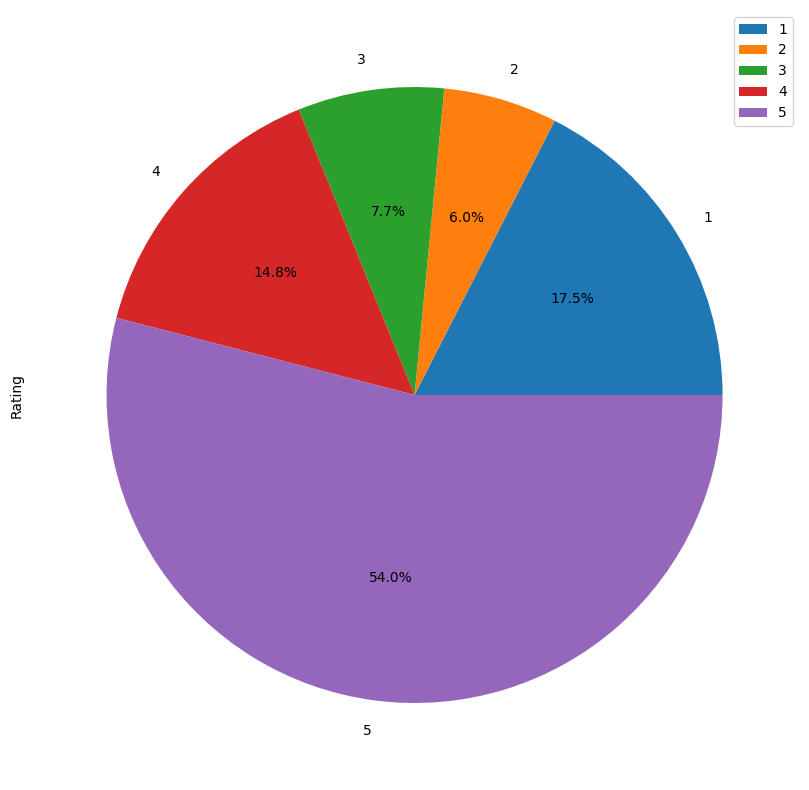

In [24]:
type_counts = dataset['Rating'].value_counts()
df = pd.DataFrame({'Rating': type_counts}, 
                     index = [1, 2, 3, 4, 5])
df.plot.pie(y='Rating', figsize=(10,10), autopct='%1.1f%%')

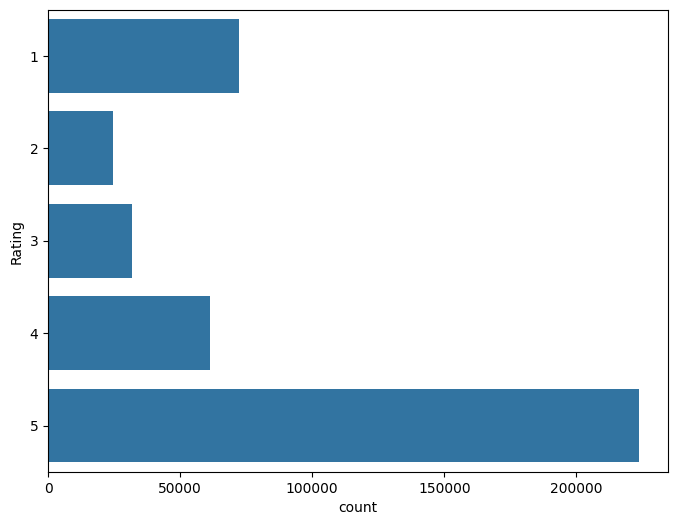

In [25]:
labels = dataset[['Rating']]
plt.figure(figsize=(8,6))
sns.countplot(y='Rating', data=labels)
plt.show()

<Axes: ylabel='Label'>

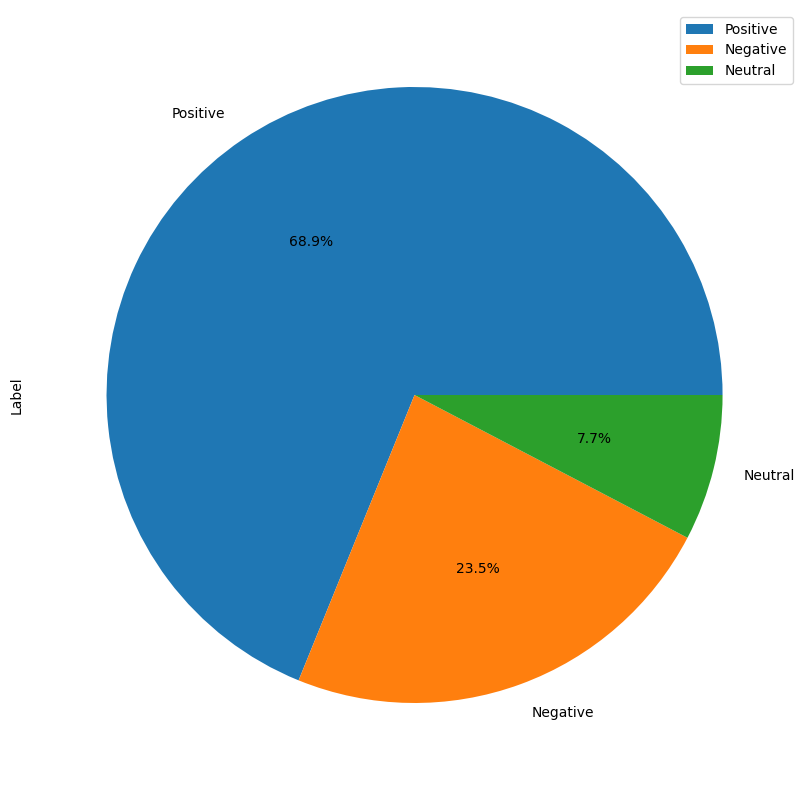

In [26]:
type_counts = filtered_dataset['Label'].value_counts()
df2 = pd.DataFrame({'Label': type_counts}, 
                     index = ['Positive', 'Negative', 'Neutral'])
df2.plot.pie(y='Label', figsize=(10,10), autopct='%1.1f%%')

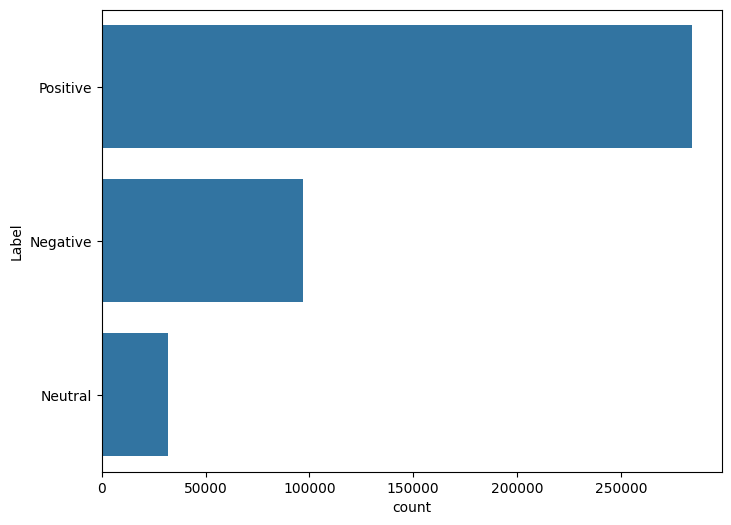

In [27]:
labels = filtered_dataset[['Label']]
plt.figure(figsize=(8,6))
sns.countplot(y='Label', data=labels)
plt.show()

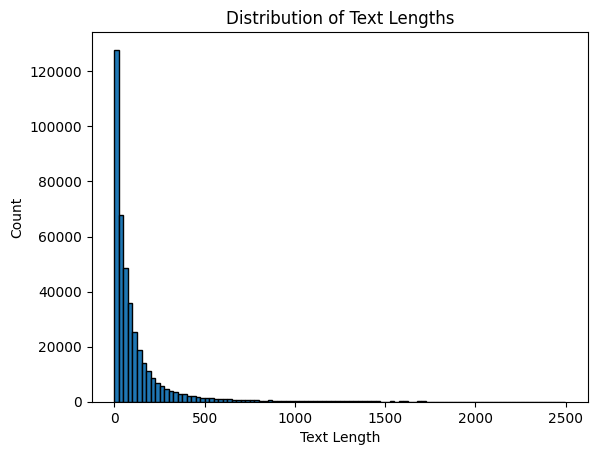

In [28]:
text_lengths = filtered_dataset['CleanReviews'].apply(len)

plt.hist(text_lengths, bins=100, edgecolor='black')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.title('Distribution of Text Lengths')

plt.show()

In [29]:

def plot_wordcloud(text, mask=None, max_words=200, max_font_size=100, figure_size=(16, 8), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'one', 'br', 'Po', 'th', 'sayi', 'fo', 'Unknown', 'phone'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='black',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    width=800, 
                    height=400,
                    mask = mask)
    wordcloud.generate(str(text))
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud)
        plt.title(title, fontdict={'size': title_size, 'color': 'black', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off')
    plt.tight_layout()  
    

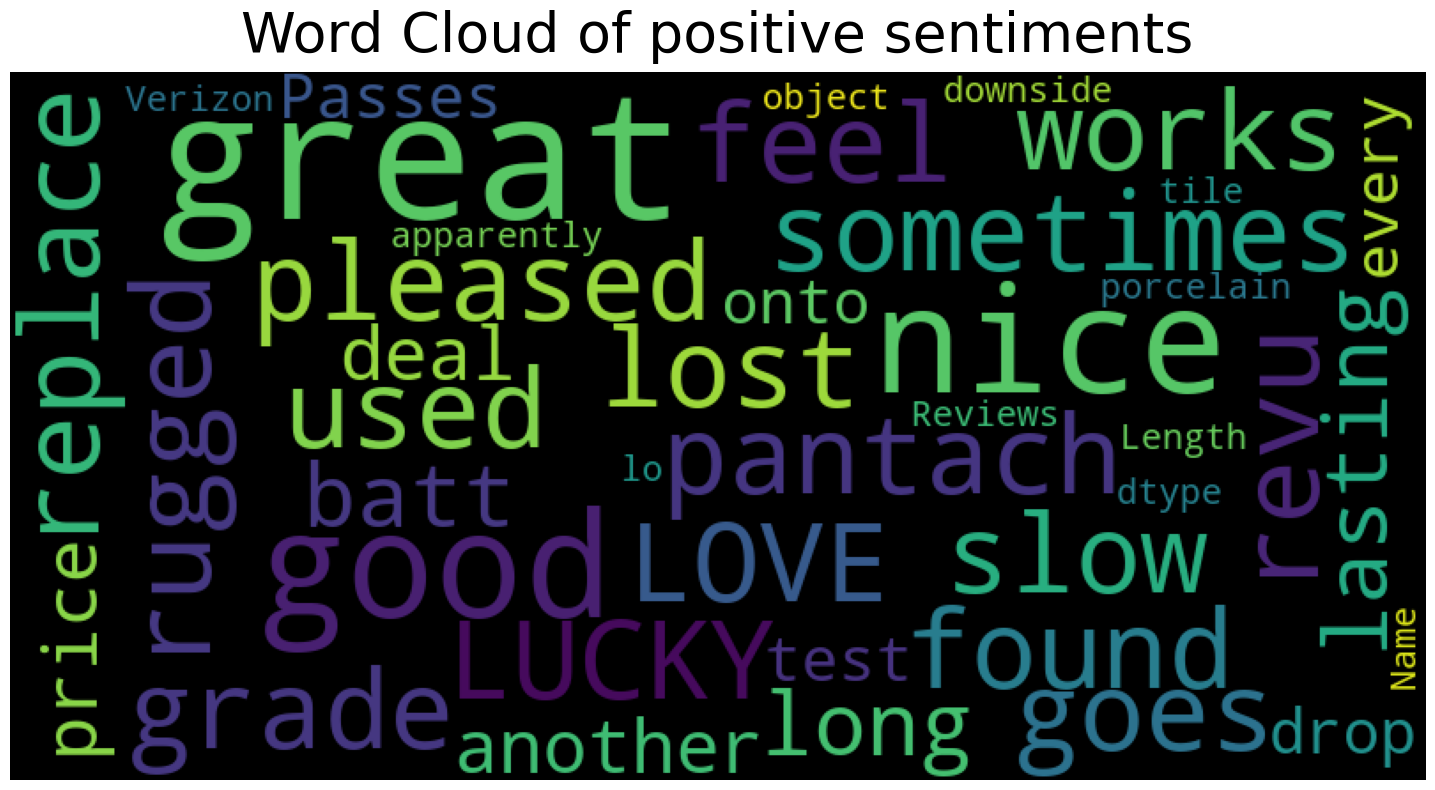

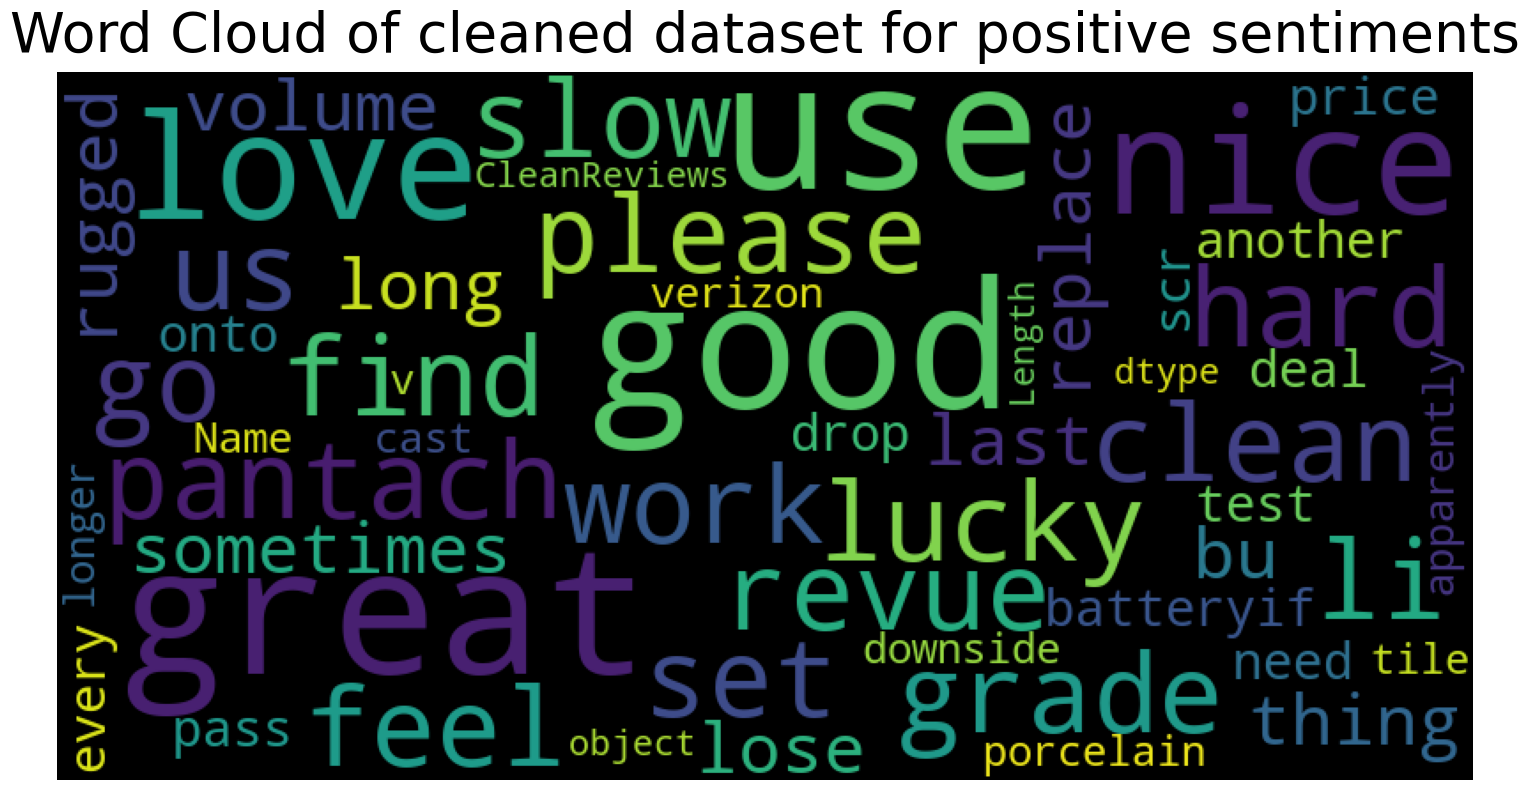

In [30]:
plot_wordcloud(positive_dataset['Reviews'], title="Word Cloud of positive sentiments")
plot_wordcloud(positive_dataset['CleanReviews'], title="Word Cloud of cleaned dataset for positive sentiments")

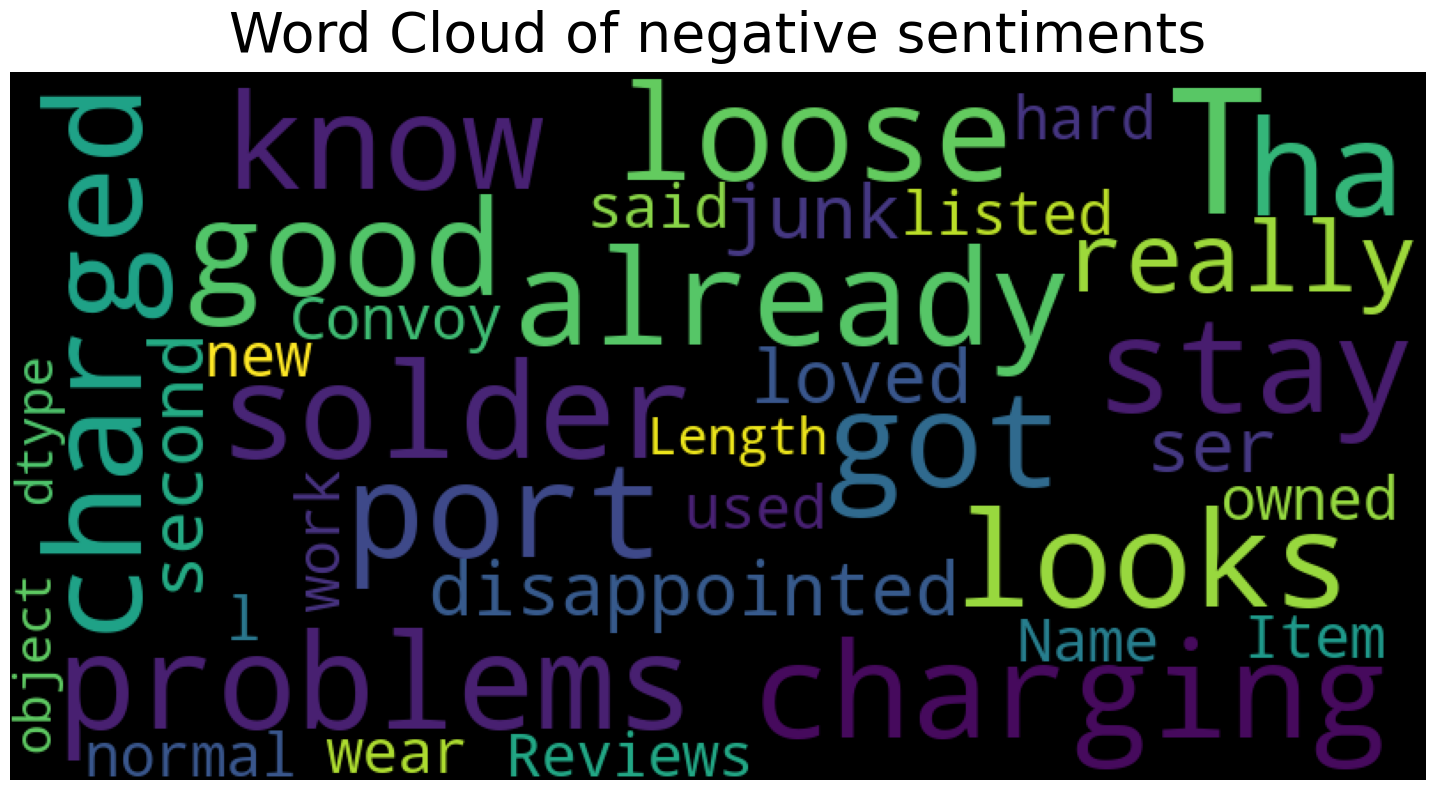

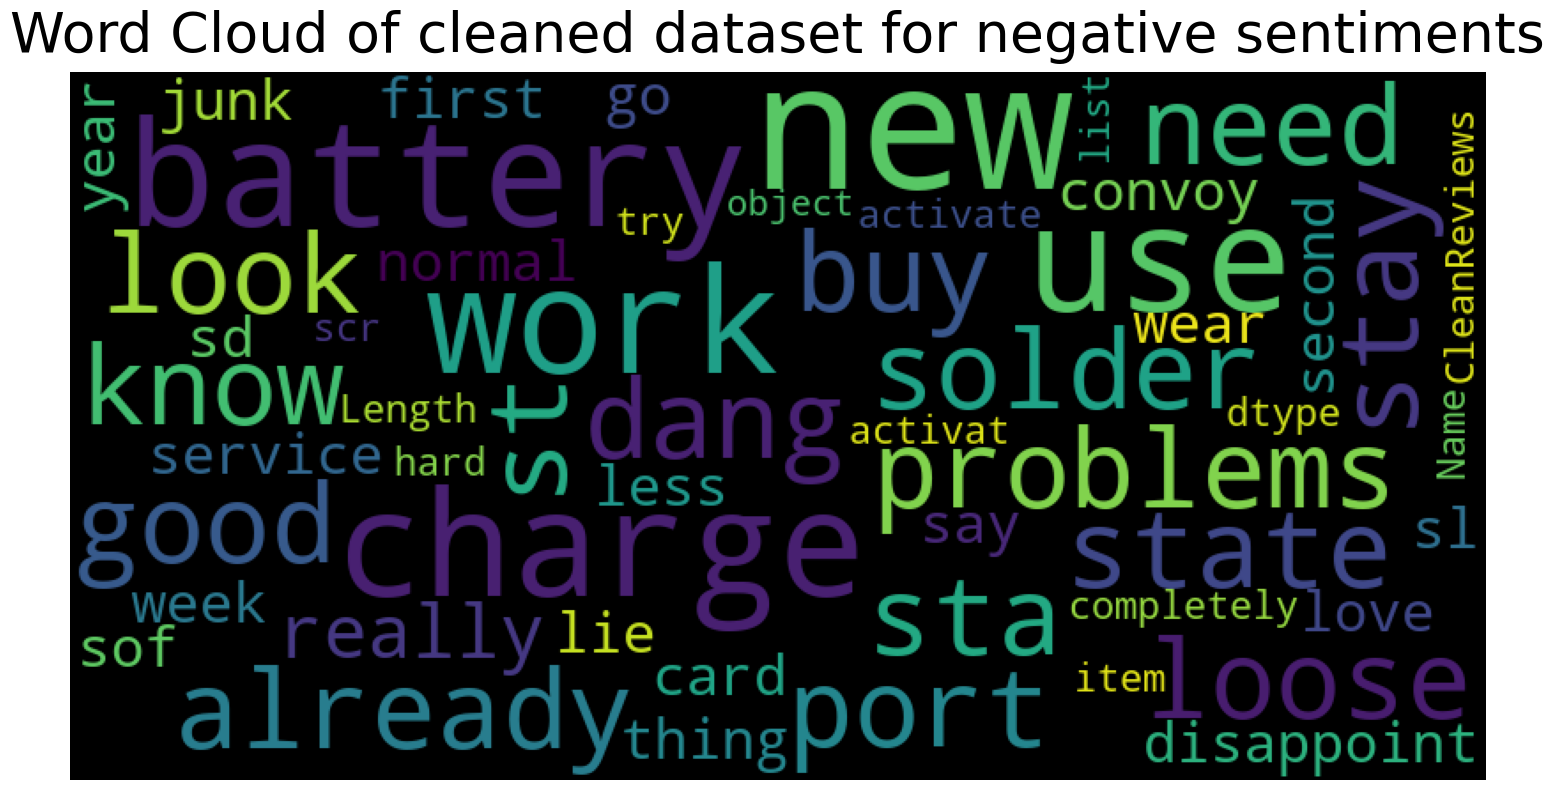

In [31]:
plot_wordcloud(negative_dataset['Reviews'], title="Word Cloud of negative sentiments")
plot_wordcloud(negative_dataset['CleanReviews'], title="Word Cloud of cleaned dataset for negative sentiments")

In [32]:
def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(" ") if token != "" if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [" ".join(ngram) for ngram in ngrams]

def horizontal_bar_chart(df, color):
    trace = go.Bar(
        y=df["word"].values[::-1],
        x=df["wordcount"].values[::-1],
        showlegend=False,
        orientation = 'h',
        marker=dict(
            color=color,
        ),
    )
    return trace

common_words = ['phone', 'phone.', 'phone,', 'will', 'one', 'screen', 'battery', 'even', 'use', 'it.']

freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent):
        if word not in common_words:
            freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent):
        if word not in common_words:
            freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,
                          subplot_titles=["Frequent words of positive reviews", 
                                          "Frequent words of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Word Count Plots")
py.iplot(fig, filename='word-plots')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [33]:
freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'orange')


freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'orange')

# Creating two subplots
fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,horizontal_spacing=0.15,
                          subplot_titles=["Frequent bigrams of positive reviews", 
                                          "Frequent bigrams of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Bigram Count Plots")
py.iplot(fig, filename='word-plots')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'orange')


freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'orange')

# Creating two subplots
fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,horizontal_spacing=0.15,
                          subplot_titles=["Frequent bigrams of positive reviews", 
                                          "Frequent bigrams of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=1200, paper_bgcolor='rgb(233,233,233)', title="Bigram Count Plots")
py.iplot(fig, filename='word-plots')

# Bag of Words Transformation vs TF-IDF Transformation

## Includes:
- Bow transformations
- Tf-Idf transformations
- Training Classification algorithms

In [34]:
training_data, test_data = train_test_split(finetuning_reduced_filtered_dataset, train_size = 0.7, random_state=42)

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
bow_vectorizer = CountVectorizer(lowercase=False)

X = bow_vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,1,1,0,1,0,1,0,1,...,1,1,1,1,0,1,1,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,3,1,0,...,0,0,0,0,1,0,0,2,2,1


In [38]:
tfidf_transform = TfidfTransformer(norm=None)
X = tfidf_transform.fit_transform(X)
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.405465,0.000000
1,0.000000,2.098612,2.098612,2.098612,0.000000,2.098612,0.000000,1.693147,0.000000,2.098612,...,2.098612,2.098612,2.098612,2.098612,0.000000,2.098612,2.098612,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.405465,0.000000
3,2.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.098612,5.079442,2.098612,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.098612,0.000000,0.000000,4.197225,2.810930,2.098612


In [41]:
vectorizer = TfidfVectorizer(use_idf=False) 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,0.25000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000
1,0.000000,0.108465,0.108465,0.108465,0.00000,0.108465,0.000000,0.108465,0.000000,0.108465,...,0.108465,0.108465,0.108465,0.108465,0.000000,0.108465,0.108465,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.57735,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.577350,0.000000
3,0.447214,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.141421,0.424264,0.141421,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.141421,0.000000,0.000000,0.282843,0.282843,0.141421


In [42]:
vectorizer = TfidfVectorizer() 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,0.214109,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.177730,0.00000
1,0.000000,0.109271,0.109271,0.109271,0.000000,0.109271,0.00000,0.088160,0.00000,0.109271,...,0.109271,0.109271,0.109271,0.109271,0.00000,0.109271,0.109271,0.000000,0.000000,0.00000
2,0.000000,0.000000,0.000000,0.000000,0.556816,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.462208,0.00000
3,0.447214,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.15179,0.367389,0.15179,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.15179,0.000000,0.000000,0.303579,0.203310,0.15179


Priprema podataka

In [43]:
bow_transform = CountVectorizer(lowercase=False) 
X_tr_bow = bow_transform.fit_transform(training_data['CleanReviews'])
y_tr = training_data['Label']

y_bow_transform = CountVectorizer(lowercase=False) 

y_tr_transformed_using_bow = y_bow_transform.fit_transform(training_data['Label'])

print("Shape of X_tr_bow: ", X_tr_bow.shape)
print("Shape of y_tr: ", y_tr.shape)

print("len(bow_transform.vocabulary_): ", len(bow_transform.vocabulary_))

X_te_bow = bow_transform.transform(test_data['CleanReviews'])
y_te = test_data['Label']

y_te_transformed_using_bow = y_bow_transform.transform(test_data['Label'])

print("Shape of X_te_bow: ", X_te_bow.shape)
print("Shape of y_te: ", y_te.shape)

print("Shape of y_tr_transformed_using_bow: ", y_tr_transformed_using_bow.shape)
print("Shape of y_te_transformed_using_bow: ", y_te_transformed_using_bow.shape)


Shape of X_tr_bow:  (7000, 6442)
Shape of y_tr:  (7000,)
len(bow_transform.vocabulary_):  6442
Shape of X_te_bow:  (3000, 6442)
Shape of y_te:  (3000,)
Shape of y_tr_transformed_using_bow:  (7000, 3)
Shape of y_te_transformed_using_bow:  (3000, 3)


In [44]:

tfidf_transform = TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_transform.fit_transform(X_tr_bow)
X_te_tfidf = tfidf_transform.transform(X_te_bow)

y_tfidf_transform = TfidfTransformer(norm=None)

y_tr_transformed_using_TfIdfTransformer = y_tfidf_transform.fit_transform(y_tr_transformed_using_bow)
y_te_transformed_using_TfIdfTransformer = y_tfidf_transform.transform(y_te_transformed_using_bow)

print("Shape of X_tr_tfidf: ", X_tr_tfidf.shape)
print("Shape of X_te_tfidf: ", X_te_tfidf.shape)

print("Shape of y_tr_transformed_using_TfIdfTransformer: ", y_tr_transformed_using_TfIdfTransformer.shape)
print("Shape of y_te_transformed_using_TfIdfTransformer: ", y_te_transformed_using_TfIdfTransformer.shape)



Shape of X_tr_tfidf:  (7000, 6442)
Shape of X_te_tfidf:  (3000, 6442)
Shape of y_tr_transformed_using_TfIdfTransformer:  (7000, 3)
Shape of y_te_transformed_using_TfIdfTransformer:  (3000, 3)


In [45]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_tfidf_tr = tfidf_vectorizer.fit_transform(training_data['CleanReviews'])
X_tfidf_te = tfidf_vectorizer.transform(test_data['CleanReviews'])

y_tfidf_vectorizer = TfidfVectorizer()
y_tr_transformed_using_TfidfVectorizer = y_tfidf_vectorizer.fit_transform(training_data['Label'])
y_te_transformed_using_TfidfVectorizer = y_tfidf_vectorizer.transform(test_data['Label'])

print("Shape of X_tfidf_tr: ", X_tfidf_tr.shape)
print("Shape of X_tfidf_te: ", X_tfidf_te.shape)

print("Shape of y_tr_transformed_using_TfidfVectorizer: ", y_tr_transformed_using_TfidfVectorizer.shape)
print("Shape of y_te_transformed_using_TfidfVectorizer: ", y_te_transformed_using_TfidfVectorizer.shape)



Shape of X_tfidf_tr:  (7000, 6442)
Shape of X_tfidf_te:  (3000, 6442)
Shape of y_tr_transformed_using_TfidfVectorizer:  (7000, 3)
Shape of y_te_transformed_using_TfidfVectorizer:  (3000, 3)
